# De novo indel (ID83) signature definition

Matches the 4 de novo ID83 signatures (from `SupTable14_Discovered_deNovo_ID_Signatures.csv`, 83 channels × 4 signatures) to the COSMIC v3.4 ID reference catalog.

1. Load the 4 de novo ID83 signatures.
2. Plot the signatures.
3. Compare each to the candidate COSMIC v3.4 ID signatures via cosine similarity and a constrained COSMIC mixture (the paper-figure labels).

In [1]:
# --- Nature figure style: 0.25 lw spines/ticks, no top/right spines ---
import matplotlib as mpl
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "font.size": 9,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
    "xtick.minor.width": 0.25, "ytick.minor.width": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

def nature_axes(ax, keep_top=False):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(keep_top)
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    ax.tick_params(width=0.25)
    return ax

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.spatial.distance as spd
import scipy.optimize as sp
import musical

SUPP_TABLE = "../supplemental_tables_v2/SupTable14_Discovered_deNovo_ID_Signatures.csv"
COSMIC     = "data/SuppFig_deNovo_ID_signature_definition/COSMIC_v3.4_ID_GRCh37.txt"  # tab-separated, index 'Type'
ID_PANEL   = ["ID1","ID2","ID4","ID5","ID6","ID8","ID9","ID11","ID12","ID19","ID21"]

OUT = "../output/SuppFig_deNovo_ID_signature_definition"
os.makedirs(OUT, exist_ok=True)

## 1. Load the de novo ID83 signatures (supplemental table)


In [3]:
deNovoSigs = pd.read_csv(SUPP_TABLE, index_col=0)
deNovoSigs.index.name = "MutationType"
print("de novo signatures:", deNovoSigs.shape)
deNovoSigs.head()

de novo signatures: (83, 4)


,Signature 1,Signature 2,Signature 3,Signature 4
MutationType,,,,
1:Del:C:0,0.022047,0.031526,0.020373,0.115545
1:Del:C:1,0.005869,0.028735,0.026422,0.033473
1:Del:C:2,0.003936,0.012449,0.024641,0.010395
1:Del:C:3,0.002049,0.003159,0.004326,0.018961
1:Del:C:4,0.002912,0.005077,0.006913,0.001143


## 2. Plot the 4 de novo ID83 signatures


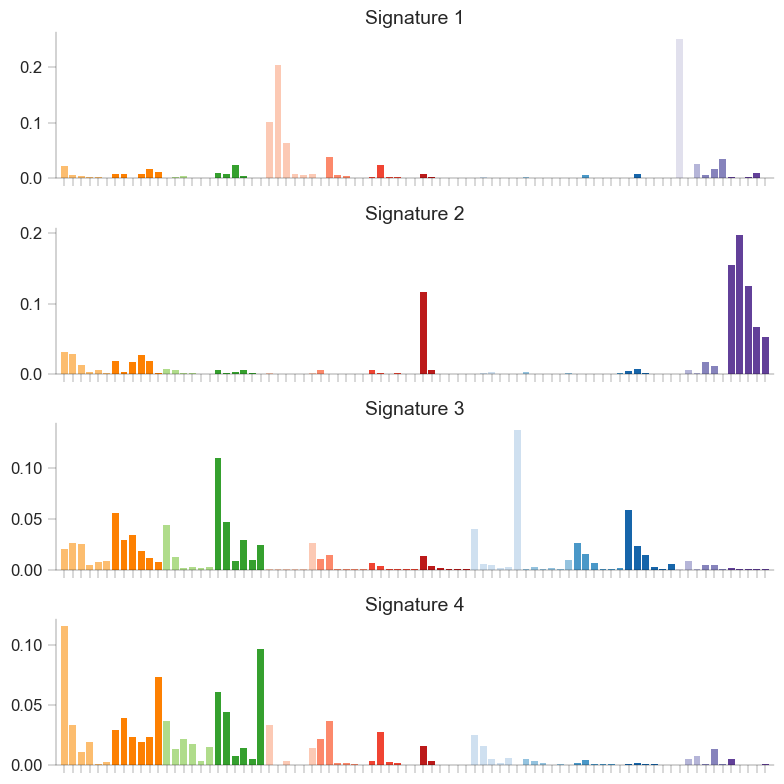

In [4]:
fig = musical.sigplot_bar(deNovoSigs, sig_type="Indel83", axis_linewidth=0.25)
fig = fig if fig is not None else plt.gcf()
for ax in fig.get_axes():
    nature_axes(ax)
fig.savefig(f"{OUT}/deNovo_ID83_signatures.pdf", bbox_inches="tight")
plt.show()

## 3. Compare the de novo signatures to known COSMIC ID signatures

Cosine similarity of each de novo signature to each candidate COSMIC v3.4 ID signature; the
best match names the signature (e.g. Signature 1 ≈ ID4).

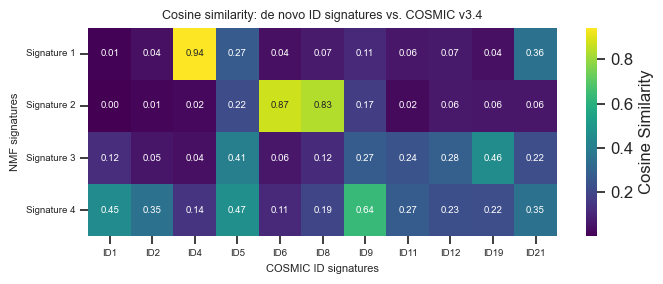

,Best COSMIC,Cosine similarity
Signature 1,ID4,0.94
Signature 2,ID6,0.87
Signature 3,ID19,0.46
Signature 4,ID9,0.64


In [5]:
def cosine_similarity_to_cosmic(W_nmf, cosmic_filepath, panel):
    cosmic = pd.read_csv(cosmic_filepath, sep="\t").set_index("Type")
    W_nmf = pd.DataFrame(W_nmf.values, index=cosmic.index, columns=W_nmf.columns)
    W_cosmic = cosmic[panel].loc[W_nmf.index]

    sim_df = pd.DataFrame(index=W_nmf.columns, columns=W_cosmic.columns, dtype=float)
    for sig in W_nmf.columns:
        target = W_nmf[sig].values
        sim_df.loc[sig] = [1 - spd.cosine(W_cosmic[c], target) for c in W_cosmic.columns]

    fig, ax = plt.subplots(figsize=(7, 3))
    sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="viridis",
                cbar_kws={"label": "Cosine Similarity"}, annot_kws={"fontsize": 7}, ax=ax)
    ax.set_title("Cosine similarity: de novo ID signatures vs. COSMIC v3.4", fontsize=9)
    ax.set_xlabel("COSMIC ID signatures", fontsize=8); ax.set_ylabel("NMF signatures", fontsize=8)
    ax.tick_params(labelsize=7); plt.yticks(rotation=0)
    fig.tight_layout()
    fig.savefig(f"{OUT}/deNovo_ID83_cosine_heatmap.pdf", bbox_inches="tight")
    plt.show()

    best = pd.DataFrame({"Best COSMIC": sim_df.idxmax(axis=1),
                         "Cosine similarity": sim_df.max(axis=1).round(2)})
    return sim_df, best

sim_df, best_match = cosine_similarity_to_cosmic(deNovoSigs, COSMIC, ID_PANEL)
best_match

### 3b. Reproduce the paper-figure labels (best constrained COSMIC mixture)

Each de novo signature is decomposed into a non-negative, sum-to-one COSMIC-panel mixture by
minimising cosine distance (SLSQP); the poorly reconstructed one is reported as **de novo**.

In [6]:
def figure_labels_from_mixture(W_nmf, cosmic_filepath, panel, n_top=3, novel_thresh=0.85):
    cosmic = pd.read_csv(cosmic_filepath, sep="\t").set_index("Type")
    W_nmf = pd.DataFrame(W_nmf.values, index=cosmic.index, columns=W_nmf.columns)
    W_cosmic = cosmic[panel].loc[W_nmf.index]

    def objective(coeffs, M, target):
        return spd.cosine(M @ coeffs, target)

    rows = []
    for sig in W_nmf.columns:
        target = W_nmf[sig].values; M = W_cosmic.values
        x0 = np.ones(M.shape[1]) / M.shape[1]
        constraints = [{"type": "ineq", "fun": lambda x: x},
                       {"type": "eq",   "fun": lambda x: np.sum(x) - 1},
                       {"type": "ineq", "fun": lambda x: 1 - x}]
        res = sp.minimize(objective, x0, args=(M, target), method="SLSQP", constraints=constraints)
        coeffs = pd.Series(res.x, index=panel).sort_values(ascending=False)
        top = coeffs[coeffs > 0.05].head(n_top)
        cos_sim = round(1 - res.fun, 2)
        label = "de novo" if cos_sim < novel_thresh else ",".join(top.index)
        rows.append({"Signature": sig, "Label": label, "Cosine similarity": cos_sim,
                     "Top coefficients": {k: round(v, 2) for k, v in top.items()}})
    return pd.DataFrame(rows).set_index("Signature")

figure_labels = figure_labels_from_mixture(deNovoSigs, COSMIC, ID_PANEL)
figure_labels

,Label,Cosine similarity,Top coefficients
Signature,,,
Signature 1,"ID4,ID5",0.95,"{'ID4': 0.86, 'ID5': 0.05}"
Signature 2,"ID6,ID8",0.99,"{'ID6': 0.52, 'ID8': 0.43}"
Signature 3,de novo,0.62,"{'ID5': 0.31, 'ID19': 0.29, 'ID12': 0.14}"
Signature 4,"ID9,ID21,ID11",0.90,"{'ID9': 0.36, 'ID21': 0.19, 'ID11': 0.12}"
